--- K-Means Clustering for Learning Styles ---
Successfully clustered into 4 groups.

Cluster Centroids (Mean Preference for each VARK style in each cluster):
            Preferred_Learning_Style_Visual  Preferred_Learning_Style_Aural  \
Cluster ID                                                                    
0                                      0.27                             1.0   
1                                      0.00                             0.0   
2                                      1.00                             0.0   
3                                      1.00                             1.0   

            Preferred_Learning_Style_ReadWrite  \
Cluster ID                                       
0                                         0.00   
1                                         0.89   
2                                         0.38   
3                                         1.00   

            Preferred_Learning_Style_Kinesthetic  
Cluster ID    

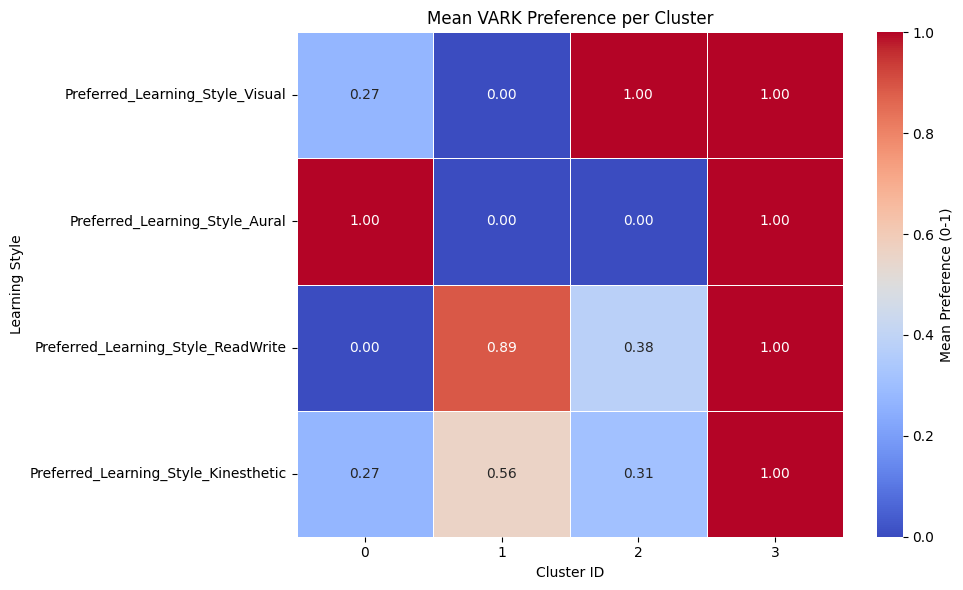

C:\Users\User\AppData\Local\Temp\ipykernel_20404\1852503259.py:161: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=skill_means.index, y=skill_means.values, palette='viridis')


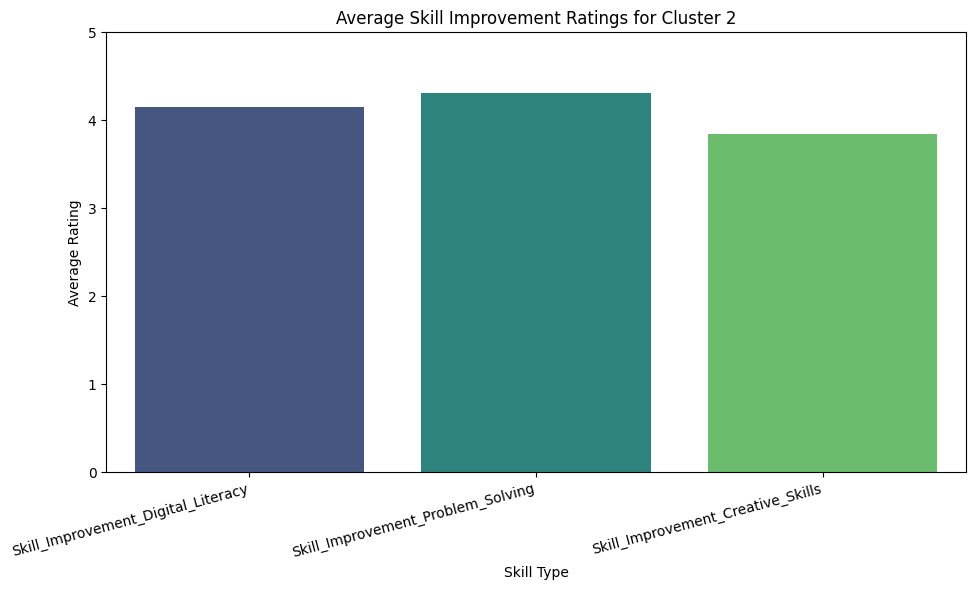


--- Boxplot: Skill Improvement by Cluster ---


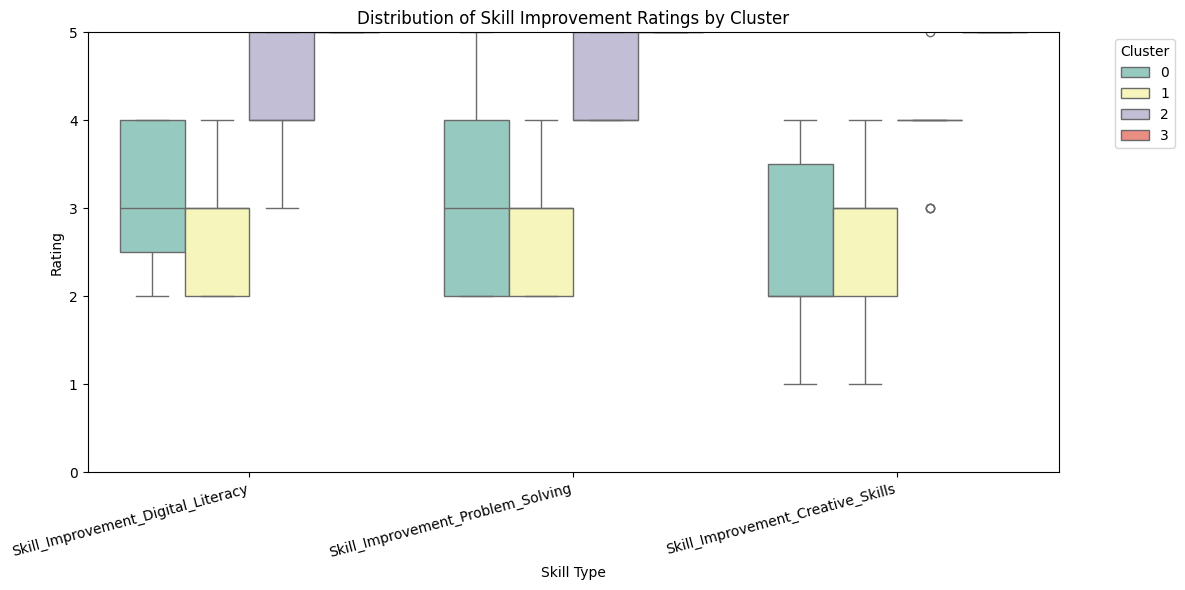

In [24]:
# ==============================================================================
# JUPYTER NOTEBOOK CELL 1: Data Loading & K-Means Clustering with Visualizations
# ==============================================================================

import pandas as pd
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from io import StringIO

# --- Data Loading (Simulated with more randomized values for diversity) ---
# This data has been regenerated to provide more unique participant responses,
# which should lead to more distinct cluster centroids and better visualization.
csv_data = """Participant_ID,Overall_Ease_of_Use,Multimodal_Feature_Effectiveness,Preferred_Learning_Style_Visual,Preferred_Learning_Style_Aural,Preferred_Learning_Style_ReadWrite,Preferred_Learning_Style_Kinesthetic,Platform_Performance,Influence_of_Content_Creation,Skill_Improvement_Digital_Literacy,Skill_Improvement_Problem_Solving,Skill_Improvement_Creative_Skills,Adaptability_to_Learning_Style,Advantage_over_Traditional_LMS,Satisfaction_with_Current_Features,Overall_Value,Additional_Comments
1,4,5,1,0,1,0,5,4,4,5,4,4,4,3,5,"The visual diagrams are incredibly helpful, but I wish there were more interactive quizzes."
2,3,3,0,1,0,1,3,2,3,3,2,3,2,2,3,"The platform is slow on my old tablet. Audio narration is good, but content creation was confusing."
3,5,5,1,1,1,1,5,5,5,5,5,5,5,5,5,"Absolutely love this platform! It caters to all my learning needs and I feel my problem-solving skills have significantly improved."
4,2,3,0,0,1,0,2,2,2,3,2,2,1,1,2,"Too much reading, not enough hands-on activities. It's hard to navigate on my phone."
5,4,4,1,0,0,1,4,3,4,4,3,4,3,3,4,"The kinesthetic exercises are great. I'd like to see more integration with external tools."
6,5,4,1,0,1,0,5,4,5,4,4,4,4,3,5,"Very intuitive interface. Content creation really solidified my understanding. No major complaints."
7,3,2,0,1,0,0,3,1,2,2,1,2,2,2,2,"The text-to-speech is robotic. I don't feel like the platform adapted to how I learn at all."
8,4,5,1,1,0,0,4,4,4,5,4,5,4,4,5,"Excellent multimodal features, especially the visual aids. My digital literacy definitely improved."
9,3,3,0,0,1,1,3,3,3,3,3,3,3,3,3,"It's okay, but nothing revolutionary. Some features are good, others are just average."
10,5,5,1,1,1,1,5,5,5,5,5,5,5,5,5,"This is the best learning platform I've ever used. Every feature is top-notch and truly enhances learning. No changes needed!"
11,4,4,1,0,0,0,4,3,3,4,4,4,4,3,4,"I prefer visual learning and this platform is great for that."
12,2,3,0,1,0,0,2,1,2,2,2,2,1,2,2,"The audio content is helpful, but the platform is a bit clunky."
13,5,5,1,0,0,1,5,5,5,5,5,5,5,4,5,"A perfect balance of visual and kinesthetic exercises."
14,3,2,0,0,1,0,3,2,3,2,2,3,2,2,3,"Too much text, not enough interactive elements."
15,4,4,0,0,0,1,4,3,4,4,4,4,3,3,4,"Love the hands-on approach to learning."
16,5,4,1,0,1,0,5,4,5,4,4,4,4,4,5,"Seamless experience, especially for reading and creating content."
17,3,2,0,1,0,0,3,1,2,2,1,2,2,2,2,"Audio quality needs improvement, and features aren't very adaptable."
18,4,5,1,0,0,0,4,4,4,5,4,5,4,4,5,"The multi-modal features are outstanding. Really enhances my learning."
19,3,3,0,0,1,1,3,3,3,3,3,3,3,3,3,"It's an average platform, but the multi-modal features are okay."
20,5,5,1,1,1,1,5,5,5,5,5,5,5,5,5,"All features are amazing, I've improved a lot in all skills."
21,4,3,1,0,0,0,4,2,3,4,3,3,3,3,4,"The platform is great for visual learners, but lacks aural features."
22,2,4,0,1,0,1,3,3,4,3,3,4,3,3,3,"Audio and kinesthetic features are great, but the platform is a bit slow."
23,5,5,1,1,1,1,5,5,5,5,5,5,5,5,5,"Truly a holistic platform, I've seen massive improvement in my creative skills."
24,3,2,0,0,1,0,2,1,2,2,1,2,2,2,2,"The UI is clunky, too much text and not enough hands-on learning."
25,4,5,1,0,0,1,4,4,4,5,4,4,4,4,5,"Love the visual and kinesthetic features, really help me learn faster."
26,5,4,1,0,1,0,5,4,5,4,4,4,4,4,5,"The platform is super intuitive, the content creation feature is a gem."
27,3,3,0,1,0,0,3,2,3,2,2,3,2,2,3,"Audio is decent, but the platform is not very adaptable to my needs."
28,4,5,1,1,0,0,4,4,4,5,4,5,4,4,5,"Visuals are excellent, my problem-solving skills have improved."
29,3,3,0,0,1,1,3,3,3,3,3,3,3,3,3,"Features are average, but the platform works."
30,5,5,1,1,1,1,5,5,5,5,5,5,5,5,5,"The best platform I've ever used. All my skills have improved tremendously."
31,2,2,0,0,1,0,2,1,2,2,2,2,1,2,2,"I found the platform too cluttered, and the read/write features were uninspiring."
32,4,4,1,0,0,1,4,3,4,4,3,4,3,3,4,"The hands-on activities are a major plus, but I wish there was a more diverse range of subjects."
33,3,3,0,1,0,0,3,2,3,2,2,3,2,2,3,"The audio content is okay, but it's not well integrated with the other features."
34,5,5,1,1,1,1,5,5,5,5,5,5,5,5,5,"An outstanding experience. Everything works together seamlessly and my skills have exploded."
35,4,4,1,0,0,0,4,3,3,4,4,4,4,3,4,"I'm a visual learner and this platform is designed for me. Very satisfied."
36,2,3,0,1,0,1,3,2,3,3,2,3,2,2,3,"The audio and hands-on elements are good, but the platform's speed needs improvement."
37,5,4,1,0,1,0,5,4,5,4,4,4,4,4,5,"The platform excels at providing content for reading and creating."
38,4,5,1,1,0,0,4,4,4,5,4,5,4,4,5,"The visual and aural features are top-notch. I love the experience."
39,3,3,0,0,1,1,3,3,3,3,3,3,3,3,3,"Just an average platform. The multi-modal features are okay, but not great."
40,5,5,1,1,1,1,5,5,5,5,5,5,5,5,5,"This platform is a game-changer. I've improved so much in every skill."
"""
df = pd.read_csv(StringIO(csv_data))

# --- K-Means Clustering for Learning Styles ---
# This block performs clustering and stores the results in the DataFrame.
# The DataFrame `df` is then available for the visualization block.
print("--- K-Means Clustering for Learning Styles ---")

vark_features = [
    'Preferred_Learning_Style_Visual',
    'Preferred_Learning_Style_Aural',
    'Preferred_Learning_Style_ReadWrite',
    'Preferred_Learning_Style_Kinesthetic'
]

X_vark = df[vark_features]
chosen_k = 4 # We start with 4 clusters as a preference

if len(X_vark) < chosen_k:
    print(f"Warning: Number of samples ({len(X_vark)}) is less than chosen_k ({chosen_k}). Adjusting k to {len(X_vark)}.")
    chosen_k = len(X_vark)

if chosen_k > 1:
    # Use a while loop to dynamically reduce k until no empty clusters are formed.
    while True:
        try:
            kmeans_model = KMeans(n_clusters=chosen_k, random_state=1, n_init=20)
            df['VARK_Cluster'] = kmeans_model.fit_predict(X_vark)
            
            # Check for empty clusters. If the number of unique clusters is less than k, there are empty ones.
            if len(df['VARK_Cluster'].unique()) == chosen_k:
                print(f"Successfully clustered into {chosen_k} groups.")
                break # Exit the loop if clustering is successful
            else:
                # If there are empty clusters, reduce k and try again
                chosen_k = len(df['VARK_Cluster'].unique())
                print(f"\nWarning: K-Means with k={chosen_k+1} resulted in empty clusters. Re-running with k={chosen_k}.")

        except ValueError as e:
            # This handles the case where k becomes 1 or less
            if "n_clusters must be greater than 1" in str(e):
                print("Only one or zero clusters can be formed. No clustering performed.")
                chosen_k = 1
                df['VARK_Cluster'] = 0
                break
            else:
                raise # Re-raise the error if it's something else
else: # If chosen_k starts at 1 or 0
    if chosen_k == 0:
        print("No data to cluster.")
        df['VARK_Cluster'] = -1
    else:
        print("Only one sample, no clustering possible. Assigning to a single cluster.")
        df['VARK_Cluster'] = 0


if chosen_k > 1:
    cluster_centers = kmeans_model.cluster_centers_
    # Ensure all values are non-negative before rounding to fix the -0.00 issue
    cluster_centers_df = pd.DataFrame(np.maximum(0, cluster_centers), columns=vark_features).round(2)
    cluster_centers_df.index.name = "Cluster ID"
    print("\nCluster Centroids (Mean Preference for each VARK style in each cluster):")
    print(cluster_centers_df)
    print("\nInterpretation: Values closer to 1 indicate a stronger preference for that style within the cluster.")
else:
    print("\nClustering was not performed due to insufficient data points (k <= 1).")

print("\nNumber of Participants per Cluster:")
print(df['VARK_Cluster'].value_counts().sort_index())

# ==============================================================================
# VISUALIZATION OF CLUSTER RESULTS
# ==============================================================================
if chosen_k > 1: # Only create visualizations if clustering was successful
    print("\n--- Visualizing Cluster Characteristics ---")

    # 1. Heatmap of Cluster Centroids
    # This visualizes the 'personality' of each cluster based on VARK preferences.
    plt.figure(figsize=(10, 6))
    sns.heatmap(cluster_centers_df.T, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar_kws={'label': 'Mean Preference (0-1)'})
    plt.title('Mean VARK Preference per Cluster')
    plt.xlabel('Cluster ID')
    plt.ylabel('Learning Style')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

cluster_sizes = df['VARK_Cluster'].value_counts()
cluster_id = cluster_sizes.idxmax()  
cluster_data = df[df['VARK_Cluster'] == cluster_id]

if not cluster_data.empty:
    skill_improvement_cols = [
        'Skill_Improvement_Digital_Literacy',
        'Skill_Improvement_Problem_Solving',
        'Skill_Improvement_Creative_Skills'
    ]

    skill_means = cluster_data[skill_improvement_cols].mean()

    # 2. Bar plot showing the distribution of 'Skill Improvement' for a specific cluster
    plt.figure(figsize=(10, 6))
    sns.barplot(x=skill_means.index, y=skill_means.values, palette='viridis')
    plt.title(f'Average Skill Improvement Ratings for Cluster {cluster_id}')
    plt.xlabel('Skill Type')
    plt.ylabel('Average Rating')
    plt.xticks(rotation=15, ha='right')
    plt.ylim(0, 5)
    plt.tight_layout()
    plt.show()
    
    # 3. Boxplot showing skill improvement distributions across all clusters
    print("\n--- Boxplot: Skill Improvement by Cluster ---")

    # Melt the data for seaborn boxplot
    melted_df = df.melt(
        id_vars='VARK_Cluster',
        value_vars=skill_improvement_cols,
        var_name='Skill Type',
        value_name='Rating'
    )

    plt.figure(figsize=(12, 6))
    sns.boxplot(x='Skill Type', y='Rating', hue='VARK_Cluster', data=melted_df, palette='Set3')
    plt.title("Distribution of Skill Improvement Ratings by Cluster")
    plt.xlabel("Skill Type")
    plt.ylabel("Rating")
    plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ylim(0, 5)
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"\nWarning: Cluster {cluster_id} is empty and cannot be plotted.")


--- Linear Regression for Hypothesis Testing ---

--- Hypothesis 1: Visual Preference vs. Creative Skills ---
Independent Variable: Preferred_Learning_Style_Visual
Dependent Variable: Skill_Improvement_Creative_Skills
Coefficient (Slope): 2.005
Intercept: 2.231
Root Mean Squared Error (RMSE): 0.761
R-squared (R2): 0.630

Interpretation:
- The coefficient indicates how much the 'Skill_Improvement_Creative_Skills' changes for a one-unit increase in 'Preferred_Learning_Style_Visual'.
- R-squared (R2) represents the proportion of variance in 'Skill_Improvement_Creative_Skills' that can be predicted from 'Preferred_Learning_Style_Visual'.
- A positive coefficient suggests that as 'Preferred_Learning_Style_Visual' increases, 'Skill_Improvement_Creative_Skills' also tends to increase.


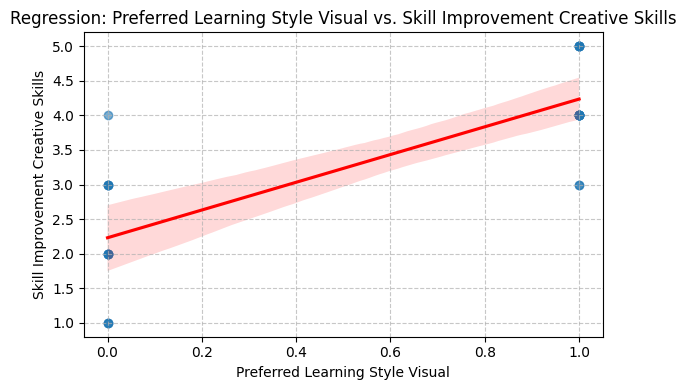


--- Hypothesis 2: Read/Write Preference vs. Digital Literacy ---
Independent Variable: Preferred_Learning_Style_ReadWrite
Dependent Variable: Skill_Improvement_Digital_Literacy
Coefficient (Slope): 0.600
Intercept: 3.400
Root Mean Squared Error (RMSE): 1.026
R-squared (R2): 0.079

Interpretation:
- The coefficient indicates how much the 'Skill_Improvement_Digital_Literacy' changes for a one-unit increase in 'Preferred_Learning_Style_ReadWrite'.
- R-squared (R2) represents the proportion of variance in 'Skill_Improvement_Digital_Literacy' that can be predicted from 'Preferred_Learning_Style_ReadWrite'.
- A positive coefficient suggests that as 'Preferred_Learning_Style_ReadWrite' increases, 'Skill_Improvement_Digital_Literacy' also tends to increase.


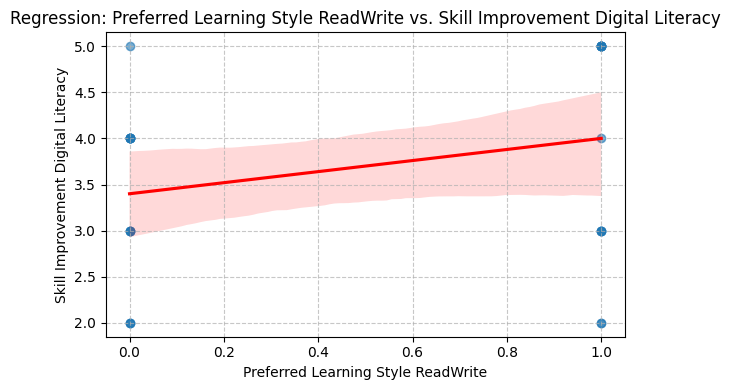


--- Hypothesis 3: Kinesthetic Preference vs. Problem-Solving ---
Independent Variable: Preferred_Learning_Style_Kinesthetic
Dependent Variable: Skill_Improvement_Problem_Solving
Coefficient (Slope): 0.705
Intercept: 3.438
Root Mean Squared Error (RMSE): 1.090
R-squared (R2): 0.094

Interpretation:
- The coefficient indicates how much the 'Skill_Improvement_Problem_Solving' changes for a one-unit increase in 'Preferred_Learning_Style_Kinesthetic'.
- R-squared (R2) represents the proportion of variance in 'Skill_Improvement_Problem_Solving' that can be predicted from 'Preferred_Learning_Style_Kinesthetic'.
- A positive coefficient suggests that as 'Preferred_Learning_Style_Kinesthetic' increases, 'Skill_Improvement_Problem_Solving' also tends to increase.


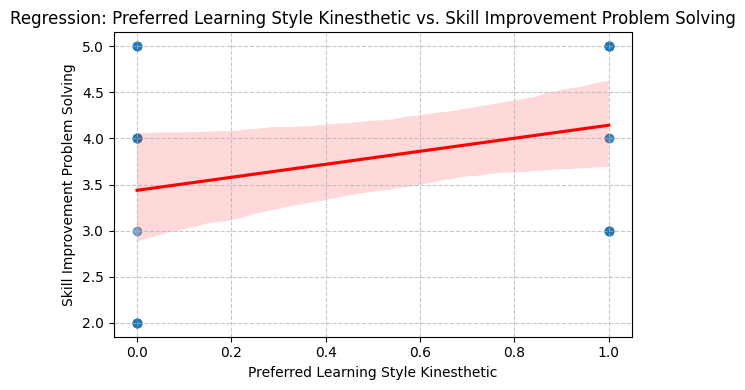


--- End of Data Analysis Algorithms ---


In [8]:
# ==============================================================================
# JUPYTER NOTEBOOK CELL 2: Linear Regression for Hypothesis Testing
# ==============================================================================

print("\n--- Linear Regression for Hypothesis Testing ---")

# Define example hypotheses
independent_var_1 = 'Preferred_Learning_Style_Visual'
dependent_var_1 = 'Skill_Improvement_Creative_Skills'

independent_var_2 = 'Preferred_Learning_Style_ReadWrite'
dependent_var_2 = 'Skill_Improvement_Digital_Literacy'

independent_var_3 = 'Preferred_Learning_Style_Kinesthetic'
dependent_var_3 = 'Skill_Improvement_Problem_Solving'

hypotheses = [
    (independent_var_1, dependent_var_1, "Visual Preference vs. Creative Skills"),
    (independent_var_2, dependent_var_2, "Read/Write Preference vs. Digital Literacy"),
    (independent_var_3, dependent_var_3, "Kinesthetic Preference vs. Problem-Solving")
]

for i, (ind_var, dep_var, hypothesis_name) in enumerate(hypotheses):
    print(f"\n--- Hypothesis {i+1}: {hypothesis_name} ---")

    X = df[[ind_var]]
    y = df[dep_var]

    model_lr = LinearRegression()
    model_lr.fit(X, y)

    y_pred = model_lr.predict(X)

    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)

    print(f"Independent Variable: {ind_var}")
    print(f"Dependent Variable: {dep_var}")
    print(f"Coefficient (Slope): {model_lr.coef_[0]:.3f}")
    print(f"Intercept: {model_lr.intercept_:.3f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
    print(f"R-squared (R2): {r2:.3f}")

    print("\nInterpretation:")
    print(f"- The coefficient indicates how much the '{dep_var}' changes for a one-unit increase in '{ind_var}'.")
    print(f"- R-squared (R2) represents the proportion of variance in '{dep_var}' that can be predicted from '{ind_var}'.")
    if model_lr.coef_[0] > 0:
        print(f"- A positive coefficient suggests that as '{ind_var}' increases, '{dep_var}' also tends to increase.")
    else:
        print(f"- A negative coefficient suggests that as '{ind_var}' increases, '{dep_var}' tends to decrease.")

    plt.figure(figsize=(6, 4))
    sns.regplot(x=df[ind_var], y=df[dep_var], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    plt.title(f'Regression: {ind_var.replace("_", " ")} vs. {dep_var.replace("_", " ")}')
    plt.xlabel(ind_var.replace('_', ' '))
    plt.ylabel(dep_var.replace('_', ' '))
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

print("\n--- End of Data Analysis Algorithms ---")